# STEP 1: Data Loading, Cleaning & Patient-Level Split

In [ ]:
!wget -r -N -c -np https://physionet.org/files/hillel-yaffe-glaucoma-dataset/1.0.0/

Streaming output truncated to the last 5000 lines.
Length: 133386 (130K) [image/jpeg]
Saving to: ‘physionet.org/files/hillel-yaffe-glaucoma-dataset/1.0.0/Images/17_1.jpg’

physionet.org/files 100%[===================>] 130.26K   189KB/s    in 0.7s    

2026-05-16 06:30:04 (189 KB/s) - ‘physionet.org/files/hillel-yaffe-glaucoma-dataset/1.0.0/Images/17_1.jpg’ saved [133386/133386]

--2026-05-16 06:30:04--  https://physionet.org/files/hillel-yaffe-glaucoma-dataset/1.0.0/Images/17_2.jpg
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 133122 (130K) [image/jpeg]
Saving to: ‘physionet.org/files/hillel-yaffe-glaucoma-dataset/1.0.0/Images/17_2.jpg’

physionet.org/files 100%[===================>] 130.00K   181KB/s    in 0.7s    

2026-05-16 06:30:05 (181 KB/s) - ‘physionet.org/files/hillel-yaffe-glaucoma-dataset/1.0.0/Images/17_2.jpg’ saved [133122/133122]

--2026-05-16 06:30:05--  https://physionet.org/files/hillel-yaffe-glaucoma-dataset/

--- Informasi Tabel Label ---
Total Data: 747 gambar
  Image Name  Patient Label  Quality Score  Unnamed: 4
0    0_0.jpg        0  GON+           6.18         NaN
1    1_0.jpg        1  GON+           5.31         NaN
2    1_1.jpg        1  GON+           4.37         NaN
3    2_0.jpg        2  GON+           3.51         NaN
4    2_1.jpg        2  GON+           4.24         NaN

Distribusi Penyakit (0: Sehat, 1: Glaukoma):
Label
GON+    548
GON-    199
Name: count, dtype: int64


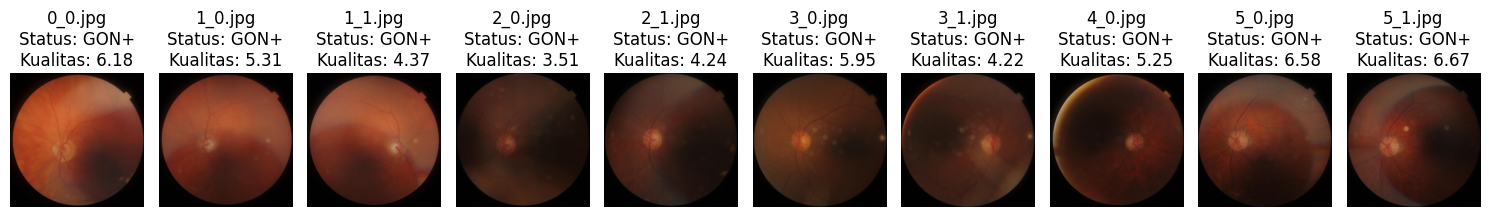

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os

# Menentukan jalur folder hasil unduhan
base_path = "physionet.org/files/hillel-yaffe-glaucoma-dataset/1.0.0/"
image_dir = os.path.join(base_path, "Images")
csv_path = os.path.join(base_path, "Labels.csv")

def muat_dan_tampilkan_data(label_path, img_folder):
    if not os.path.exists(label_path):
        print("File CSV tidak ditemukan!")
        return

    df = pd.read_csv(label_path)

    print("--- Informasi Tabel Label ---")
    print(f"Total Data: {len(df)} gambar")
    print(df.head())

    # Menghitung distribusi label (Sehat vs Glaukoma)
    print("\nDistribusi Penyakit (0: Sehat, 1: Glaukoma):")
    print(df['Label'].value_counts())

    # Visualisasi 3 sampel gambar pertama dari tabel
    plt.figure(figsize=(15, 5))
    for i in range(10):
        nama_file = df.iloc[i]['Image Name']
        label_medis = df.iloc[i]['Label']
        skor_kualitas = df.iloc[i]['Quality Score']

        img_path = os.path.join(img_folder, nama_file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, 10, i+1)
        plt.imshow(img)
        plt.title(f"{nama_file}\nStatus: {label_medis}\nKualitas: {skor_kualitas}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

muat_dan_tampilkan_data(csv_path, image_dir)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

df = pd.read_csv(csv_path)

# Bersihkan kolom yang tidak perlu
df = df.drop(columns=['Unnamed: 4'], errors='ignore')

# Konversi label ke binary
df['label_binary'] = df['Label'].map({'GON+': 1, 'GON-': 0})

# Quality Gate: buang gambar QS < 3
df_filtered = df[df['Quality Score'] >= 3].copy()
print(f"Gambar sebelum filter: {len(df)}")
print(f"Gambar setelah filter QS < 3: {len(df_filtered)}")

# PATIENT-LEVEL SPLIT (ini yang paling penting!)
# Satu pasien tidak boleh muncul di train DAN test sekaligus
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

groups = df_filtered['Patient'].values
X = df_filtered['Image Name'].values
y = df_filtered['label_binary'].values

train_idx, test_idx = next(gss.split(X, y, groups=groups))

df_train = df_filtered.iloc[train_idx].reset_index(drop=True)
df_test  = df_filtered.iloc[test_idx].reset_index(drop=True)

# Verifikasi tidak ada patient yang bocor
train_patients = set(df_train['Patient'].unique())
test_patients  = set(df_test['Patient'].unique())
overlap        = train_patients & test_patients

print(f"\nTotal pasien: {df_filtered['Patient'].nunique()}")
print(f"Pasien di train: {len(train_patients)}")
print(f"Pasien di test : {len(test_patients)}")
print(f"Overlap pasien : {len(overlap)} ← harus 0!")

print(f"\nGambar train: {len(df_train)}")
print(f"Gambar test : {len(df_test)}")

print(f"\nDistribusi label train:")
print(df_train['label_binary'].value_counts())
print(f"\nDistribusi label test:")
print(df_test['label_binary'].value_counts())

Gambar sebelum filter: 747
Gambar setelah filter QS < 3: 741

Total pasien: 286
Pasien di train: 228
Pasien di test : 58
Overlap pasien : 0 ← harus 0!

Gambar train: 589
Gambar test : 152

Distribusi label train:
label_binary
1    442
0    147
Name: count, dtype: int64

Distribusi label test:
label_binary
1    100
0     52
Name: count, dtype: int64


# STEP 2: Exploratory Data Analysis & Statistical Quality Analysis

STATISTIK DESKRIPTIF QUALITY SCORE PER KELAS
         N  Mean    Std  Median    Q25   Q75   Min   Max
Label                                                   
GON+   542  5.88  0.992   6.175  5.322  6.61  3.08  7.69
GON-   199  6.07  0.873   6.220  5.630  6.65  3.20  7.68

MANN-WHITNEY U TEST: Quality Score GON+ vs GON-
H0: Distribusi QS GON+ = GON- (tidak berbeda signifikan)
U-statistic  : 49501.00
p-value      : 0.0864
Effect size r: 0.4589
Interpretasi : Gagal tolak H0 | Effect size: medium

KRUSKAL-WALLIS TEST: QS antar Quality Tier
H-statistic  : nan
p-value      : nan
Interpretasi : Tidak berbeda signifikan

DISTRIBUSI GAMBAR PER QUALITY TIER & KELAS
Label         GON+  GON-  Total  GON+ Rate (%)
quality_tier                                  
Medium (3-5)   105    20    125           84.0
High (>5)      437   179    616           70.9
Total          542   199    741           73.1

JUMLAH PASIEN UNIK PER QUALITY TIER
Low (<3)            :    0 gambar |    0 pasien unik
Medium (3-

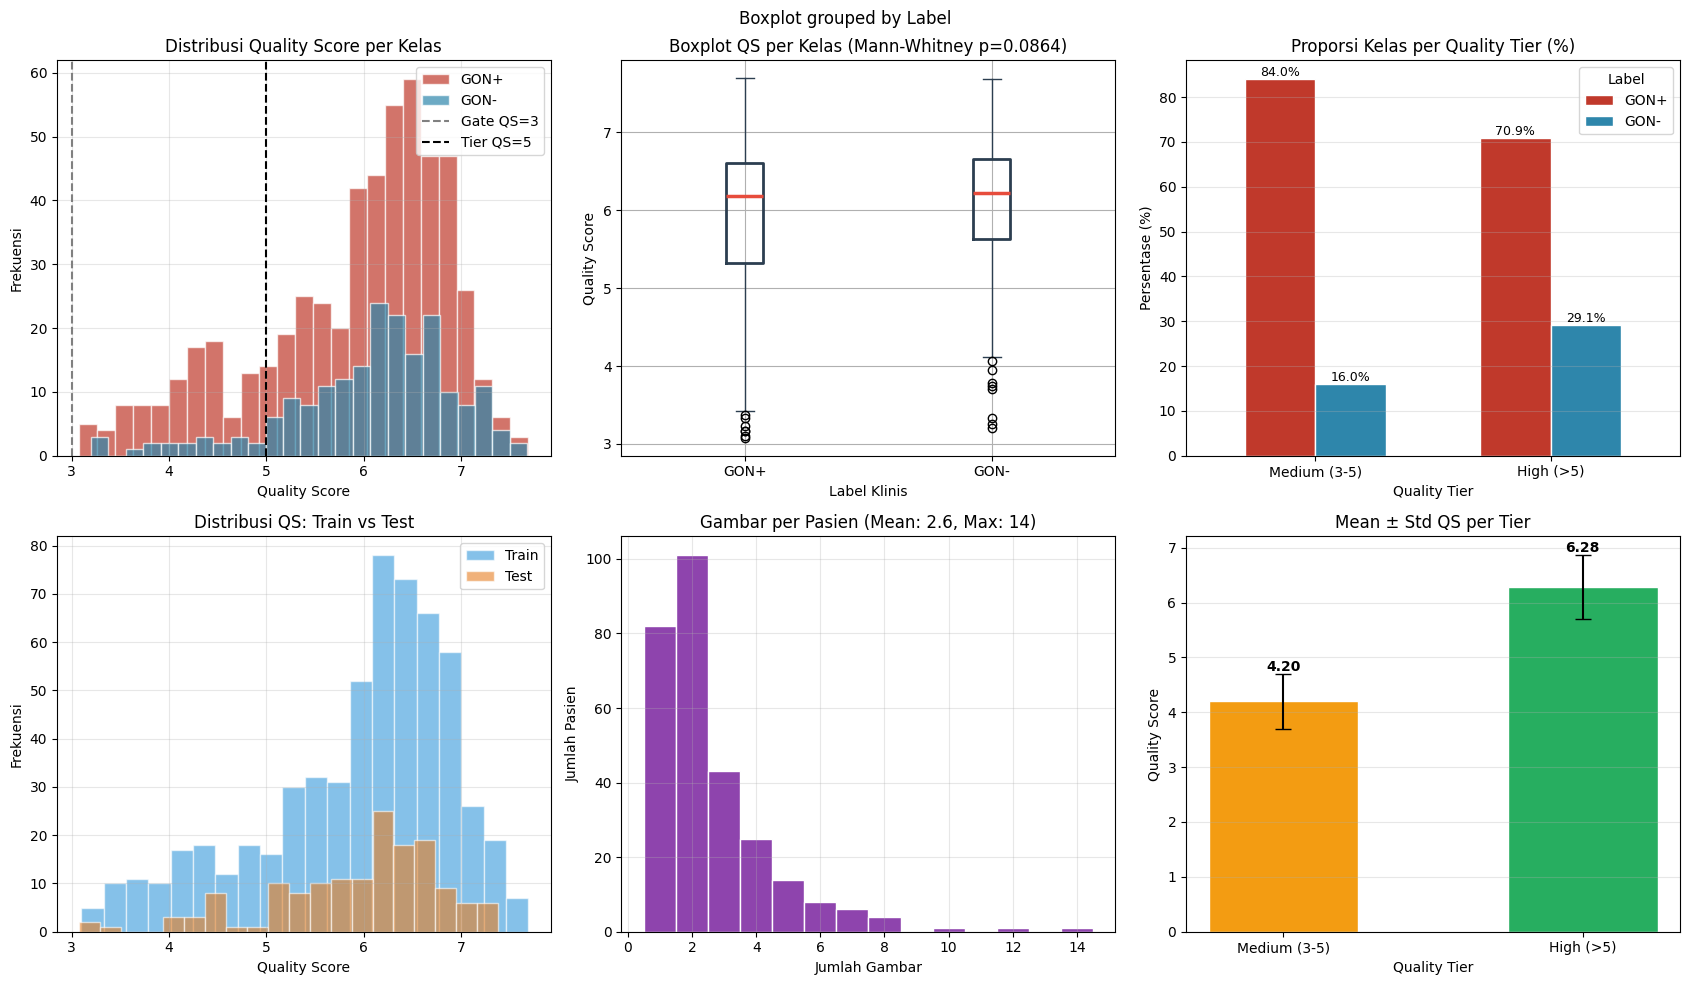

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, kruskal
import warnings
warnings.filterwarnings('ignore')

df_filtered['quality_tier'] = pd.cut(
    df_filtered['Quality Score'],
    bins=[0, 3.0, 5.0, 10.0],
    labels=['Low (<3)', 'Medium (3-5)', 'High (>5)']
)
df_train['quality_tier'] = pd.cut(
    df_train['Quality Score'],
    bins=[0, 3.0, 5.0, 10.0],
    labels=['Low (<3)', 'Medium (3-5)', 'High (>5)']
)
df_test['quality_tier'] = pd.cut(
    df_test['Quality Score'],
    bins=[0, 3.0, 5.0, 10.0],
    labels=['Low (<3)', 'Medium (3-5)', 'High (>5)']
)

print("STATISTIK DESKRIPTIF QUALITY SCORE PER KELAS")
qs_stats = df_filtered.groupby('Label')['Quality Score'].agg([
    'count', 'mean', 'std', 'median',
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75),
    'min', 'max'
]).round(3)
qs_stats.columns = ['N', 'Mean', 'Std', 'Median', 'Q25', 'Q75', 'Min', 'Max']
print(qs_stats.to_string())

qs_gon_pos = df_filtered[df_filtered['Label'] == 'GON+']['Quality Score']
qs_gon_neg = df_filtered[df_filtered['Label'] == 'GON-']['Quality Score']
u_stat, p_mw = mannwhitneyu(qs_gon_pos, qs_gon_neg, alternative='two-sided')
effect_size_r = u_stat / (len(qs_gon_pos) * len(qs_gon_neg))

print(f"\nMANN-WHITNEY U TEST: Quality Score GON+ vs GON-")
print(f"H0: Distribusi QS GON+ = GON- (tidak berbeda signifikan)")
print(f"U-statistic  : {u_stat:.2f}")
print(f"p-value      : {p_mw:.4f}")
print(f"Effect size r: {effect_size_r:.4f}")
print(f"Interpretasi : {'Tolak H0' if p_mw < 0.05 else 'Gagal tolak H0'} | Effect size: {'small' if effect_size_r < 0.3 else 'medium' if effect_size_r < 0.5 else 'large'}")

groups_kw = [
    df_filtered[df_filtered['quality_tier'] == tier]['Quality Score'].values
    for tier in ['Low (<3)', 'Medium (3-5)', 'High (>5)']
]
kw_stat, p_kw = kruskal(*groups_kw)
print(f"\nKRUSKAL-WALLIS TEST: QS antar Quality Tier")
print(f"H-statistic  : {kw_stat:.4f}")
print(f"p-value      : {p_kw:.4f}")
print(f"Interpretasi : {'Terdapat perbedaan signifikan antar tier' if p_kw < 0.05 else 'Tidak berbeda signifikan'}")

print(f"\nDISTRIBUSI GAMBAR PER QUALITY TIER & KELAS")
crosstab = pd.crosstab(
    df_filtered['quality_tier'],
    df_filtered['Label'],
    margins=True,
    margins_name='Total'
)
crosstab['GON+ Rate (%)'] = (crosstab['GON+'] / crosstab['Total'] * 100).round(1)
print(crosstab.to_string())

print(f"\nJUMLAH PASIEN UNIK PER QUALITY TIER")
for tier in ['Low (<3)', 'Medium (3-5)', 'High (>5)']:
    n_img = (df_filtered['quality_tier'] == tier).sum()
    n_pat = df_filtered[df_filtered['quality_tier'] == tier]['Patient'].nunique()
    print(f"{tier:20}: {n_img:4d} gambar | {n_pat:4d} pasien unik")

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('EDA — Quality Score Analysis | HYGD Dataset', fontsize=14, fontweight='bold')

palette = {'GON+': '#C0392B', 'GON-': '#2E86AB'}

for label, color in palette.items():
    subset = df_filtered[df_filtered['Label'] == label]['Quality Score']
    axes[0, 0].hist(subset, bins=25, alpha=0.7, label=label, color=color, edgecolor='white')
axes[0, 0].axvline(3.0, color='gray', linestyle='--', linewidth=1.5, label='Gate QS=3')
axes[0, 0].axvline(5.0, color='black', linestyle='--', linewidth=1.5, label='Tier QS=5')
axes[0, 0].set_title('Distribusi Quality Score per Kelas')
axes[0, 0].set_xlabel('Quality Score')
axes[0, 0].set_ylabel('Frekuensi')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

df_filtered.boxplot(
    column='Quality Score', by='Label', ax=axes[0, 1],
    boxprops=dict(color='#2C3E50', linewidth=2),
    medianprops=dict(color='#E74C3C', linewidth=2.5),
    whiskerprops=dict(color='#2C3E50'),
    capprops=dict(color='#2C3E50')
)
axes[0, 1].set_title(f'Boxplot QS per Kelas (Mann-Whitney p={p_mw:.4f})')
axes[0, 1].set_xlabel('Label Klinis')
axes[0, 1].set_ylabel('Quality Score')
plt.sca(axes[0, 1])
plt.title(f'Boxplot QS per Kelas (Mann-Whitney p={p_mw:.4f})')

crosstab_pct = pd.crosstab(
    df_filtered['quality_tier'],
    df_filtered['Label'],
    normalize='index'
) * 100
crosstab_pct.plot(
    kind='bar', ax=axes[0, 2],
    color=['#C0392B', '#2E86AB'],
    edgecolor='white', width=0.6
)
axes[0, 2].set_title('Proporsi Kelas per Quality Tier (%)')
axes[0, 2].set_xlabel('Quality Tier')
axes[0, 2].set_ylabel('Persentase (%)')
axes[0, 2].tick_params(axis='x', rotation=0)
axes[0, 2].legend(title='Label')
axes[0, 2].grid(alpha=0.3, axis='y')
for p in axes[0, 2].patches:
    axes[0, 2].annotate(f'{p.get_height():.1f}%',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=9)

for split, color, data in [('Train', '#3498DB', df_train), ('Test', '#E67E22', df_test)]:
    axes[1, 0].hist(data['Quality Score'], bins=20, alpha=0.6, label=split, color=color, edgecolor='white')
axes[1, 0].set_title('Distribusi QS: Train vs Test')
axes[1, 0].set_xlabel('Quality Score')
axes[1, 0].set_ylabel('Frekuensi')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

imgs_per_patient = df_filtered.groupby('Patient').size()
axes[1, 1].hist(imgs_per_patient.values, bins=range(1, imgs_per_patient.max() + 2),
                color='#8E44AD', edgecolor='white', align='left')
axes[1, 1].set_title(f'Gambar per Pasien (Mean: {imgs_per_patient.mean():.1f}, Max: {imgs_per_patient.max()})')
axes[1, 1].set_xlabel('Jumlah Gambar')
axes[1, 1].set_ylabel('Jumlah Pasien')
axes[1, 1].grid(alpha=0.3)

tier_summary = df_filtered.groupby('quality_tier')['Quality Score'].agg(['mean', 'std']).reset_index()
bars = axes[1, 2].bar(
    tier_summary['quality_tier'],
    tier_summary['mean'],
    yerr=tier_summary['std'],
    color=['#E74C3C', '#F39C12', '#27AE60'],
    edgecolor='white', capsize=6, width=0.5
)
axes[1, 2].set_title('Mean ± Std QS per Tier')
axes[1, 2].set_xlabel('Quality Tier')
axes[1, 2].set_ylabel('Quality Score')
axes[1, 2].grid(alpha=0.3, axis='y')
for bar, (_, row) in zip(bars, tier_summary.iterrows()):
    axes[1, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + row['std'] + 0.05,
                    f"{row['mean']:.2f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('step2_eda_quality.png', dpi=150, bbox_inches='tight')
plt.show()

#  Step 3: Preprocessing & Load Images ke Memori:

In [ ]:
import numpy as np
import cv2
import os
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm

IMG_SIZE = 224
IMAGE_DIR = image_dir

def load_and_preprocess(img_name, img_folder, img_size=IMG_SIZE):
    path = os.path.join(img_folder, img_name)
    img = cv2.imread(path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    img = img.astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = (img - mean) / std
    return img

QS_MEAN = df_train['Quality Score'].mean()
QS_STD  = df_train['Quality Score'].std()

def normalize_qs(qs_val):
    return (qs_val - QS_MEAN) / QS_STD

print(f"Quality Score Normalization (dari train set):")
print(f"  Mean : {QS_MEAN:.4f}")
print(f"  Std  : {QS_STD:.4f}")
print(f"  Range setelah normalisasi: [{(df_filtered['Quality Score'].min() - QS_MEAN)/QS_STD:.2f}, {(df_filtered['Quality Score'].max() - QS_MEAN)/QS_STD:.2f}]")

def load_split(dataframe, img_folder, augment=False):
    images, qs_scores, labels, skipped = [], [], [], []

    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc="Loading"):
        img = load_and_preprocess(row['Image Name'], img_folder)
        if img is None:
            skipped.append(row['Image Name'])
            continue

        if augment:
            if np.random.rand() > 0.5:
                img = np.fliplr(img)
            if np.random.rand() > 0.5:
                img = np.flipud(img)
            angle = np.random.uniform(-15, 15)
            M = cv2.getRotationMatrix2D((IMG_SIZE//2, IMG_SIZE//2), angle, 1.0)
            img = cv2.warpAffine(img, M, (IMG_SIZE, IMG_SIZE))
            factor = np.random.uniform(0.85, 1.15)
            img = np.clip(img * factor, -3, 3)

        images.append(img)
        qs_scores.append(normalize_qs(row['Quality Score']))
        labels.append(row['label_binary'])

    return (
        np.array(images, dtype=np.float32),
        np.array(qs_scores, dtype=np.float32).reshape(-1, 1),
        np.array(labels, dtype=np.float32),
        skipped
    )

print("\nMemuat data train...")
X_train_img, X_train_qs, y_train, skip_train = load_split(df_train, IMAGE_DIR, augment=True)

print("Memuat data test...")
X_test_img, X_test_qs, y_test, skip_test = load_split(df_test, IMAGE_DIR, augment=False)

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}

print(f"\nRingkasan Data yang Dimuat:")
print(f"  Train images shape : {X_train_img.shape}")
print(f"  Train QS shape     : {X_train_qs.shape}")
print(f"  Train labels       : {y_train.shape} | GON+: {int(y_train.sum())} | GON-: {int((y_train==0).sum())}")
print(f"  Test images shape  : {X_test_img.shape}")
print(f"  Test QS shape      : {X_test_qs.shape}")
print(f"  Test labels        : {y_test.shape} | GON+: {int(y_test.sum())} | GON-: {int((y_test==0).sum())}")
print(f"\nGambar dilewati (file tidak ditemukan):")
print(f"  Train: {len(skip_train)} | Test: {len(skip_test)}")
print(f"\nClass Weights (untuk atasi imbalance):")
print(f"  GON- (0): {class_weight_dict[0]:.4f}")
print(f"  GON+ (1): {class_weight_dict[1]:.4f}")
print(f"  Rasio   : {class_weight_dict[0]/class_weight_dict[1]:.4f} (GON- diberi bobot lebih tinggi)")
print(f"\nMemori yang digunakan:")
print(f"  Train  : {X_train_img.nbytes / 1e6:.1f} MB")
print(f"  Test   : {X_test_img.nbytes / 1e6:.1f} MB")
print(f"  Total  : {(X_train_img.nbytes + X_test_img.nbytes) / 1e6:.1f} MB")

Quality Score Normalization (dari train set):
  Mean : 5.9315
  Std  : 0.9900
  Range setelah normalisasi: [-2.88, 1.78]

Memuat data train...


Loading: 100%|██████████| 589/589 [00:13<00:00, 44.16it/s]


Memuat data test...


Loading: 100%|██████████| 152/152 [00:03<00:00, 43.41it/s]


Ringkasan Data yang Dimuat:
  Train images shape : (586, 224, 224, 3)
  Train QS shape     : (586, 1)
  Train labels       : (586,) | GON+: 439 | GON-: 147
  Test images shape  : (152, 224, 224, 3)
  Test QS shape      : (152, 1)
  Test labels        : (152,) | GON+: 100 | GON-: 52

Gambar dilewati (file tidak ditemukan):
  Train: 3 | Test: 0

Class Weights (untuk atasi imbalance):
  GON- (0): 1.9932
  GON+ (1): 0.6674
  Rasio   : 2.9864 (GON- diberi bobot lebih tinggi)

Memori yang digunakan:
  Train  : 352.8 MB
  Test   : 91.5 MB
  Total  : 444.4 MB


#  Step 4: Bangun Model Multimodal EfficientNetB0:

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0

tf.random.set_seed(42)

def build_glaucostat_model(img_size=224, dropout_rate=0.4):
    image_input = keras.Input(shape=(img_size, img_size, 3), name='image_input')
    quality_input = keras.Input(shape=(1,), name='quality_input')

    backbone = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=image_input)

    for layer in backbone.layers[:-30]:
        layer.trainable = False
    for layer in backbone.layers[-30:]:
        layer.trainable = True

    x = backbone.output
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn_image')(x)
    x = layers.Dropout(dropout_rate, name='drop_image')(x)

    q = layers.Dense(32, activation='relu', name='qs_dense1')(quality_input)
    q = layers.BatchNormalization(name='bn_qs')(q)
    q = layers.Dense(16, activation='relu', name='qs_dense2')(q)

    combined = layers.Concatenate(name='multimodal_fusion')([x, q])
    combined = layers.Dense(256, activation='relu', name='fc1')(combined)
    combined = layers.BatchNormalization(name='bn_fc1')(combined)
    combined = layers.Dropout(0.3, name='drop_fc1')(combined)
    combined = layers.Dense(64, activation='relu', name='fc2')(combined)
    combined = layers.Dropout(0.2, name='drop_fc2')(combined)
    output = layers.Dense(1, activation='sigmoid', name='output')(combined)

    model = Model(inputs=[image_input, quality_input], outputs=output, name='GlaucoStat')
    return model

model = build_glaucostat_model()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
frozen_params    = total_params - trainable_params

print("ARSITEKTUR GLAUCOSTAT — Quality-Aware Multimodal Transfer Learning")
print(f"\nBackbone        : EfficientNetB0 (pretrained ImageNet)")
print(f"Strategy        : Fine-tuning — 30 layer terakhir di-unfreeze")
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
print(f"Frozen params   : {frozen_params:,} ({frozen_params/total_params*100:.1f}%)")

print(f"\nDual Input:")
print(f"  image_input  : (None, 224, 224, 3) — citra fundus retina")
print(f"  quality_input: (None, 1)           — FundusQ-Net quality score")

print(f"\nAlur Arsitektur:")
print(f"  image_input → EfficientNetB0 → GAP → BN → Dropout(0.4)")
print(f"  quality_input → Dense(32) → BN → Dense(16)")
print(f"  Concatenate → Dense(256) → BN → Dropout(0.3) → Dense(64) → Dropout(0.2) → sigmoid")

print(f"\nKompilasi:")
print(f"  Optimizer : Adam (lr=1e-4)")
print(f"  Loss      : Binary Crossentropy")
print(f"  Metrics   : Accuracy, AUC, Precision, Recall")

layer_status = {'Trainable': 0, 'Frozen': 0}
for layer in model.layers:
    if hasattr(layer, 'trainable'):
        if layer.trainable:
            layer_status['Trainable'] += 1
        else:
            layer_status['Frozen'] += 1
print(f"\nStatus Layer:")
print(f"  Trainable layers: {layer_status['Trainable']}")
print(f"  Frozen layers   : {layer_status['Frozen']}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ARSITEKTUR GLAUCOSTAT — Quality-Aware Multimodal Transfer Learning

Backbone        : EfficientNetB0 (pretrained ImageNet)
Strategy        : Fine-tuning — 30 layer terakhir di-unfreeze
Total params    : 4,404,980
Trainable params: 1,848,433 (42.0%)
Frozen params   : 2,556,547 (58.0%)

Dual Input:
  image_input  : (None, 224, 224, 3) — citra fundus retina
  quality_input: (None, 1)           — FundusQ-Net quality score

Alur Arsitektur:
  image_input → EfficientNetB0 → GAP → BN → Dropout(0.4)
  quality_input → Dense(32) → BN → Dense(16)
  Concatenate → Dense(256) → BN → Dropout(0.3) → Dense(64) → Dropout(0.2) → sigmoid

Kompilasi:
  Optimizer : Adam (lr=1e-4)
  Loss      : Binary Crossentropy
  Metrics   : Accuracy, AUC, Precision, Recall

Status Layer:
  Trainable layers: 44
  Frozen layers   : 208


# Step 5: Training

Memulai training GlaucoStat...
Train: 586 gambar | Test: 152 gambar
Epochs maksimal: 50 | Batch size: 16 | EarlyStopping patience: 10
Monitor: val_auc (maximized)

Epoch 1/50
35/37 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6623 - auc: 0.7459 - loss: 0.5920 - precision: 0.8709 - recall: 0.6487
Epoch 1: val_auc improved from None to 0.81462, saving model to glaucostat_artifacts/best_model.keras

Epoch 1: finished saving model to glaucostat_artifacts/best_model.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 0.6485 - auc: 0.7110 - loss: 0.6382 - precision: 0.8478 - recall: 0.6469 - val_accuracy: 0.7500 - val_auc: 0.8146 - val_loss: 0.5709 - val_precision: 0.7583 - val_recall: 0.9100 - learning_rate: 6.2500e-06
Epoch 2/50
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6343 - auc: 0.7012 - loss: 0.6311 - precision: 0.8360 - recall: 0.6448
Epoch 2: val_auc did not improve from 0.81462
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6604 - auc: 0.7249 - loss: 0.61

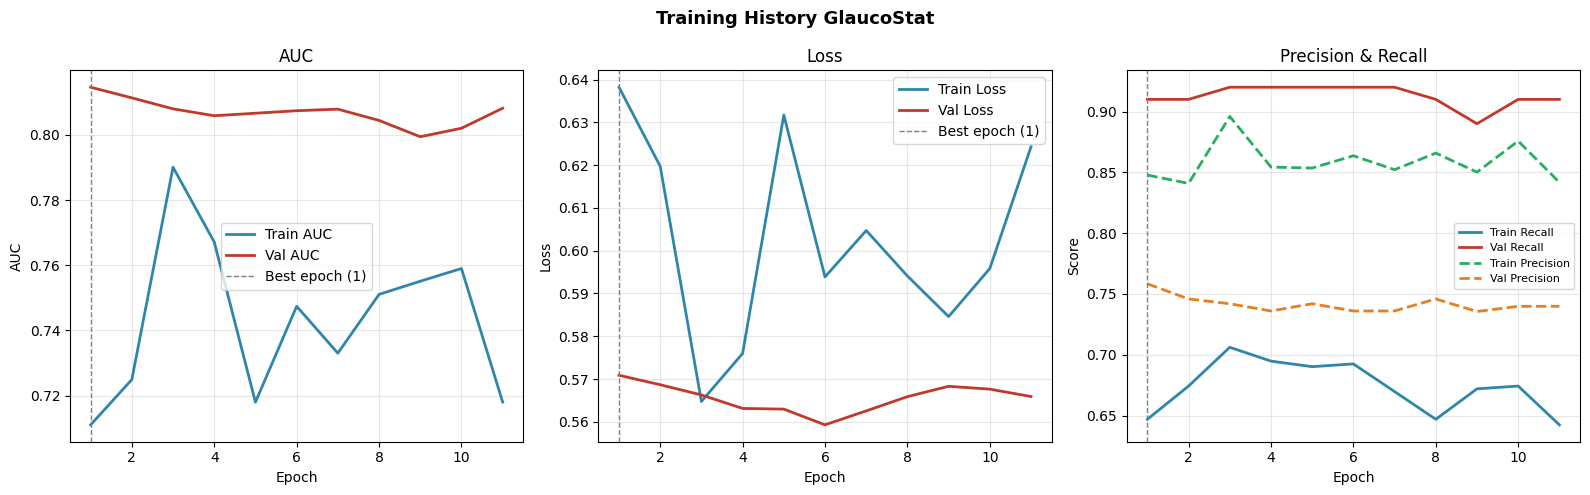

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os

os.makedirs('glaucostat_artifacts', exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=10,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=4,
        mode='max',
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='glaucostat_artifacts/best_model.keras',
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

print("Memulai training GlaucoStat...")
print(f"Train: {X_train_img.shape[0]} gambar | Test: {X_test_img.shape[0]} gambar")
print(f"Epochs maksimal: 50 | Batch size: 16 | EarlyStopping patience: 10")
print(f"Monitor: val_auc (maximized)\n")

history = model.fit(
    x={'image_input': X_train_img, 'quality_input': X_train_qs},
    y=y_train,
    validation_data=(
        {'image_input': X_test_img, 'quality_input': X_test_qs},
        y_test
    ),
    epochs=50,
    batch_size=16,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

best_epoch = int(np.argmax(history.history['val_auc'])) + 1
best_val_auc = max(history.history['val_auc'])
final_epoch = len(history.history['val_auc'])

print(f"\nTraining selesai.")
print(f"Total epoch berjalan : {final_epoch}")
print(f"Best epoch           : {best_epoch}")
print(f"Best val_auc         : {best_val_auc:.4f}")
print(f"Final train_auc      : {history.history['auc'][-1]:.4f}")
print(f"Final val_loss       : {history.history['val_loss'][-1]:.4f}")
print(f"Final val_accuracy   : {history.history['val_accuracy'][-1]:.4f}")
print(f"Final val_precision  : {history.history['val_precision'][-1]:.4f}")
print(f"Final val_recall     : {history.history['val_recall'][-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Training History GlaucoStat', fontsize=13, fontweight='bold')

epochs_range = range(1, final_epoch + 1)

axes[0].plot(epochs_range, history.history['auc'], label='Train AUC', color='#2E86AB', linewidth=2)
axes[0].plot(epochs_range, history.history['val_auc'], label='Val AUC', color='#C0392B', linewidth=2)
axes[0].axvline(best_epoch, color='gray', linestyle='--', linewidth=1, label=f'Best epoch ({best_epoch})')
axes[0].set_title('AUC')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('AUC')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history.history['loss'], label='Train Loss', color='#2E86AB', linewidth=2)
axes[1].plot(epochs_range, history.history['val_loss'], label='Val Loss', color='#C0392B', linewidth=2)
axes[1].axvline(best_epoch, color='gray', linestyle='--', linewidth=1, label=f'Best epoch ({best_epoch})')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history.history['recall'], label='Train Recall', color='#2E86AB', linewidth=2)
axes[2].plot(epochs_range, history.history['val_recall'], label='Val Recall', color='#C0392B', linewidth=2)
axes[2].plot(epochs_range, history.history['precision'], label='Train Precision', color='#27AE60', linewidth=2, linestyle='--')
axes[2].plot(epochs_range, history.history['val_precision'], label='Val Precision', color='#E67E22', linewidth=2, linestyle='--')
axes[2].axvline(best_epoch, color='gray', linestyle='--', linewidth=1)
axes[2].set_title('Precision & Recall')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Score')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('glaucostat_artifacts/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from tensorflow import keras
import numpy as np

model = keras.models.load_model('glaucostat_artifacts/best_model.keras')
print("Model berhasil diload dari checkpoint terbaik.")
print(f"Total params: {model.count_params():,}")

test_pred = model.predict(
    {'image_input': X_test_img[:5], 'quality_input': X_test_qs[:5]},
    verbose=0
)
print(f"Verifikasi prediksi (5 sampel pertama): {test_pred.flatten().round(4)}")
print(f"Label aktual                          : {y_test[:5].astype(int)}")

Model berhasil diload dari checkpoint terbaik.
Total params: 4,404,980
Verifikasi prediksi (5 sampel pertama): [0.6564 0.6472 0.8463 0.6477 0.5853]
Label aktual                          : [1 1 1 1 1]


#  Step 6: Statistical Validation + Monte Carlo Dropout

In [ ]:
import numpy as np
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, brier_score_loss,
    precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve
from scipy.stats import spearmanr, mannwhitneyu
from statsmodels.stats.contingency_tables import mcnemar as mcnemar_test
import json

# ── 1. Prediksi Deterministic (untuk semua metrik statistik) ──────
print("Prediksi deterministic (training=False)...")
y_pred_proba = model.predict(
    {'image_input': X_test_img, 'quality_input': X_test_qs},
    batch_size=16,
    verbose=0
).flatten()

point_auc = roc_auc_score(y_test, y_pred_proba)
print(f"  Point AUC (deterministic): {point_auc:.4f}")
print(f"  Pred range: min={y_pred_proba.min():.4f}, max={y_pred_proba.max():.4f}, mean={y_pred_proba.mean():.4f}")

# ── 2. MC Dropout — hanya untuk uncertainty, bukan prediksi utama ─
def mc_dropout_uncertainty(model, X_img, X_qs, n_iterations=30, batch_size=16):
    """
    Jalankan dropout aktif hanya untuk estimasi uncertainty.
    Prediksi final tetap dari model deterministic.
    """
    all_preds = []
    for _ in range(n_iterations):
        iter_preds = []
        for start in range(0, len(X_img), batch_size):
            end  = min(start + batch_size, len(X_img))
            pred = model(
                {'image_input': X_img[start:end], 'quality_input': X_qs[start:end]},
                training=True
            ).numpy().flatten()
            iter_preds.append(pred)
        all_preds.append(np.concatenate(iter_preds))
    all_preds = np.array(all_preds)
    mc_mean   = all_preds.mean(axis=0)
    mc_std    = all_preds.std(axis=0)
    return mc_mean, mc_std

print("\nMonte Carlo Dropout untuk uncertainty estimation (30 iterasi)...")
mc_mean, mc_std = mc_dropout_uncertainty(model, X_test_img, X_test_qs)

print(f"  MC uncertainty (std): min={mc_std.min():.4f}, max={mc_std.max():.4f}, mean={mc_std.mean():.4f}")

low_unc    = (mc_std < 0.05).sum()
medium_unc = ((mc_std >= 0.05) & (mc_std < 0.15)).sum()
high_unc   = (mc_std >= 0.15).sum()
print(f"\nKategori Uncertainty (MC Std):")
print(f"  Low    (std < 0.05) : {low_unc} gambar ({low_unc/len(mc_std)*100:.1f}%)")
print(f"  Medium (0.05-0.15)  : {medium_unc} gambar ({medium_unc/len(mc_std)*100:.1f}%)")
print(f"  High   (>= 0.15)    : {high_unc} gambar ({high_unc/len(mc_std)*100:.1f}%)")

# ── 3. Bootstrapped AUC 95% CI ───────────────────────────────────
def bootstrap_auc(y_true, y_pred, n_iterations=1000):
    np.random.seed(42)
    aucs = []
    n = len(y_true)
    for _ in range(n_iterations):
        idx = np.random.choice(n, n, replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_pred[idx]))
    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)
    return np.mean(aucs), lower, upper, np.std(aucs)

print("\nBootstrapping AUC (1000 iterasi)...")
auc_mean, auc_lower, auc_upper, auc_se = bootstrap_auc(y_test, y_pred_proba)
print(f"  Bootstrapped AUC : {auc_mean:.4f}")
print(f"  95% CI           : [{auc_lower:.4f}, {auc_upper:.4f}]")
print(f"  Standard Error   : {auc_se:.4f}")

# ── 4. Youden Index Threshold ─────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
youden_index    = tpr - fpr
best_idx        = np.argmax(youden_index)
opt_threshold   = thresholds[best_idx]
opt_sensitivity = tpr[best_idx]
opt_specificity = 1 - fpr[best_idx]
y_pred_binary   = (y_pred_proba >= opt_threshold).astype(int)

print(f"\nYouden Index Threshold:")
print(f"  Threshold optimal: {opt_threshold:.4f}")
print(f"  Sensitivity      : {opt_sensitivity:.4f}")
print(f"  Specificity      : {opt_specificity:.4f}")
print(f"  Youden Index     : {youden_index[best_idx]:.4f}")

# ── 5. Classification Report ──────────────────────────────────────
print(f"\nClassification Report (threshold={opt_threshold:.4f}):")
print(classification_report(
    y_test, y_pred_binary,
    target_names=['GON- (Normal)', 'GON+ (Glaukoma)'],
    digits=4
))

# ── 6. Brier Score ────────────────────────────────────────────────
brier = brier_score_loss(y_test, y_pred_proba)
print(f"Brier Score: {brier:.4f}")

# ── 7. Spearman Correlation ───────────────────────────────────────
df_test_copy = df_test.copy().reset_index(drop=True)
df_test_copy = df_test_copy.iloc[:len(y_pred_proba)].copy()
df_test_copy['y_pred_proba'] = y_pred_proba
df_test_copy['mc_std']       = mc_std
df_test_copy['pred_bin']     = y_pred_binary
qs_test_raw = df_test_copy['Quality Score'].values

spearman_rho, spearman_p = spearmanr(qs_test_raw, y_pred_proba)
spearman_unc_rho, spearman_unc_p = spearmanr(qs_test_raw, mc_std)

print(f"\nSpearman Correlation — QS vs Confidence (deterministic):")
print(f"  rho={spearman_rho:.4f}, p={spearman_p:.4f}")
print(f"  Kesimpulan: {'Tolak H0 — signifikan' if spearman_p < 0.05 else 'Gagal tolak H0'}")

print(f"\nSpearman Correlation — QS vs Uncertainty (MC Std):")
print(f"  rho={spearman_unc_rho:.4f}, p={spearman_unc_p:.4f}")
print(f"  Kesimpulan: {'Tolak H0 — QS rendah terbukti lebih uncertain' if spearman_unc_p < 0.05 else 'Gagal tolak H0'}")

# ── 8. AUC per Quality Tier ───────────────────────────────────────
print(f"\nAUC per Quality Tier:")
tier_results = {}
for tier in ['Medium (3-5)', 'High (>5)']:
    mask = df_test_copy['quality_tier'] == tier
    if mask.sum() > 5 and df_test_copy[mask]['label_binary'].nunique() > 1:
        tier_auc = roc_auc_score(
            df_test_copy[mask]['label_binary'],
            df_test_copy[mask]['y_pred_proba']
        )
        tier_results[tier] = float(tier_auc)
        print(f"  {tier:20}: AUC={tier_auc:.4f} (n={mask.sum()})")

# ── 9. McNemar Test ───────────────────────────────────────────────
high_mask   = df_test_copy['quality_tier'] == 'High (>5)'
medium_mask = df_test_copy['quality_tier'] == 'Medium (3-5)'

print(f"\nMcNemar Test: High Quality vs Medium Quality")
if high_mask.sum() > 5 and medium_mask.sum() > 5:
    correct_high   = (df_test_copy[high_mask]['pred_bin'].values == df_test_copy[high_mask]['label_binary'].values)
    correct_medium = (df_test_copy[medium_mask]['pred_bin'].values == df_test_copy[medium_mask]['label_binary'].values)
    acc_high       = correct_high.mean()
    acc_medium     = correct_medium.mean()
    print(f"  Akurasi High   (n={high_mask.sum()}): {acc_high:.4f}")
    print(f"  Akurasi Medium (n={medium_mask.sum()}): {acc_medium:.4f}")
    b              = (~correct_high).sum()
    c              = (~correct_medium).sum()
    mcnemar_table  = np.array([[correct_high.sum(), b], [c, correct_medium.sum()]])
    result_mcnemar = mcnemar_test(mcnemar_table, exact=False, correction=True)
    print(f"  Chi-square : {result_mcnemar.statistic:.4f}")
    print(f"  p-value    : {result_mcnemar.pvalue:.4f}")
    print(f"  Kesimpulan : {'Tolak H0 — error pattern berbeda signifikan' if result_mcnemar.pvalue < 0.05 else 'Gagal tolak H0'}")

# ── 10. Uncertainty per Kelas ─────────────────────────────────────
print(f"\nAnalisis Uncertainty (MC Dropout) per Kelas:")
for label, name in [(1, 'GON+ (Glaukoma)'), (0, 'GON- (Normal)')]:
    mask     = y_test == label
    mean_unc = mc_std[mask].mean()
    std_unc  = mc_std[mask].std()
    print(f"  {name}: mean uncertainty = {mean_unc:.4f} ± {std_unc:.4f}")

u_unc, p_unc = mannwhitneyu(mc_std[y_test==1], mc_std[y_test==0], alternative='two-sided')
print(f"  Mann-Whitney (uncertainty GON+ vs GON-): p={p_unc:.4f}")
print(f"  Kesimpulan: {'Uncertainty berbeda signifikan antar kelas' if p_unc < 0.05 else 'Tidak berbeda signifikan'}")

Prediksi deterministic (training=False)...
  Point AUC (deterministic): 0.8108
  Pred range: min=0.0024, max=0.9744, mean=0.5464

Monte Carlo Dropout untuk uncertainty estimation (30 iterasi)...
  MC uncertainty (std): min=0.1084, max=0.2732, mean=0.2013

Kategori Uncertainty (MC Std):
  Low    (std < 0.05) : 0 gambar (0.0%)
  Medium (0.05-0.15)  : 8 gambar (5.3%)
  High   (>= 0.15)    : 144 gambar (94.7%)

Bootstrapping AUC (1000 iterasi)...
  Bootstrapped AUC : 0.8100
  95% CI           : [0.7343, 0.8825]
  Standard Error   : 0.0393

Youden Index Threshold:
  Threshold optimal: 0.6022
  Sensitivity      : 0.7800
  Specificity      : 0.8077
  Youden Index     : 0.5877

Classification Report (threshold=0.6022):
                 precision    recall  f1-score   support

  GON- (Normal)     0.6562    0.8077    0.7241        52
GON+ (Glaukoma)     0.8864    0.7800    0.8298       100

       accuracy                         0.7895       152
      macro avg     0.7713    0.7938    0.7770   

# Step 6.5: Analisis Error

In [ ]:
print("ANALISIS ERROR False Positive & False Negative")

df_test_copy['error_type'] = 'Correct'
df_test_copy.loc[(df_test_copy['pred_bin'] == 1) & (df_test_copy['label_binary'] == 0), 'error_type'] = 'False Positive'
df_test_copy.loc[(df_test_copy['pred_bin'] == 0) & (df_test_copy['label_binary'] == 1), 'error_type'] = 'False Negative'

fp_df = df_test_copy[df_test_copy['error_type'] == 'False Positive']
fn_df = df_test_copy[df_test_copy['error_type'] == 'False Negative']
correct_df = df_test_copy[df_test_copy['error_type'] == 'Correct']

print(f"\nRingkasan Error:")
print(f"  Correct        : {len(correct_df)} gambar ({len(correct_df)/len(df_test_copy)*100:.1f}%)")
print(f"  False Positive : {len(fp_df)} gambar ({len(fp_df)/len(df_test_copy)*100:.1f}%) — Normal diprediksi Glaukoma")
print(f"  False Negative : {len(fn_df)} gambar ({len(fn_df)/len(df_test_copy)*100:.1f}%) — Glaukoma terlewat (KRITIS)")

print(f"\nAnalisis False Positive (n={len(fp_df)}):")
print(f"  Mean QS          : {fp_df['Quality Score'].mean():.4f} ± {fp_df['Quality Score'].std():.4f}")
print(f"  Mean confidence  : {fp_df['y_pred_proba'].mean():.4f} ± {fp_df['y_pred_proba'].std():.4f}")
print(f"  Mean uncertainty : {fp_df['mc_std'].mean():.4f} ± {fp_df['mc_std'].std():.4f}")
print(f"  Quality tier distribution:")
print(fp_df['quality_tier'].value_counts().to_string())

print(f"\nAnalisis False Negative (n={len(fn_df)}) Kasus Kritis:")
print(f"  Mean QS          : {fn_df['Quality Score'].mean():.4f} ± {fn_df['Quality Score'].std():.4f}")
print(f"  Mean confidence  : {fn_df['y_pred_proba'].mean():.4f} ± {fn_df['y_pred_proba'].std():.4f}")
print(f"  Mean uncertainty : {fn_df['mc_std'].mean():.4f} ± {fn_df['mc_std'].std():.4f}")
print(f"  Quality tier distribution:")
print(fn_df['quality_tier'].value_counts().to_string())

print(f"\nAnalisis Correct Predictions (n={len(correct_df)}):")
print(f"  Mean QS          : {correct_df['Quality Score'].mean():.4f} ± {correct_df['Quality Score'].std():.4f}")
print(f"  Mean confidence  : {correct_df['y_pred_proba'].mean():.4f} ± {correct_df['y_pred_proba'].std():.4f}")
print(f"  Mean uncertainty : {correct_df['mc_std'].mean():.4f} ± {correct_df['mc_std'].std():.4f}")

u_fp, p_fp = mannwhitneyu(
    fp_df['Quality Score'], correct_df['Quality Score'],
    alternative='two-sided'
) if len(fp_df) > 0 else (0, 1)
u_fn, p_fn = mannwhitneyu(
    fn_df['Quality Score'], correct_df['Quality Score'],
    alternative='two-sided'
) if len(fn_df) > 0 else (0, 1)

print(f"\nMann-Whitney U Test QS: Error vs Correct:")
print(f"  False Positive vs Correct: p={p_fp:.4f} {'QS berbeda signifikan' if p_fp < 0.05 else 'QS tidak berbeda signifikan'}")
print(f"  False Negative vs Correct: p={p_fn:.4f} {'QS berbeda signifikan' if p_fn < 0.05 else 'QS tidak berbeda signifikan'}")

u_unc_fp, p_unc_fp = mannwhitneyu(
    fp_df['mc_std'], correct_df['mc_std'],
    alternative='two-sided'
) if len(fp_df) > 0 else (0, 1)
u_unc_fn, p_unc_fn = mannwhitneyu(
    fn_df['mc_std'], correct_df['mc_std'],
    alternative='two-sided'
) if len(fn_df) > 0 else (0, 1)

print(f"\nMann-Whitney U Test — Uncertainty: Error vs Correct:")
print(f"  False Positive vs Correct: p={p_unc_fp:.4f} {'Uncertainty berbeda signifikan' if p_unc_fp < 0.05 else 'Tidak berbeda signifikan'}")
print(f"  False Negative vs Correct: p={p_unc_fn:.4f} {'Uncertainty berbeda signifikan' if p_unc_fn < 0.05 else 'Tidak berbeda signifikan'}")

high_unc_threshold = 0.20
fn_high_unc = (fn_df['mc_std'] >= high_unc_threshold).sum()
fp_high_unc = (fp_df['mc_std'] >= high_unc_threshold).sum()
correct_high_unc = (correct_df['mc_std'] >= high_unc_threshold).sum()

print(f"\nPotensi MC Dropout sebagai Flag Review Manual (uncertainty >= {high_unc_threshold}):")
print(f"  False Negative dengan high uncertainty : {fn_high_unc}/{len(fn_df)} ({fn_high_unc/len(fn_df)*100:.1f}% kasus kritis bisa diflag)")
print(f"  False Positive dengan high uncertainty : {fp_high_unc}/{len(fp_df)} ({fp_high_unc/len(fp_df)*100:.1f}%)")
print(f"  Correct dengan high uncertainty        : {correct_high_unc}/{len(correct_df)} ({correct_high_unc/len(correct_df)*100:.1f}%)")

ANALISIS ERROR False Positive & False Negative

Ringkasan Error:
  Correct        : 120 gambar (78.9%)
  False Positive : 10 gambar (6.6%) — Normal diprediksi Glaukoma
  False Negative : 22 gambar (14.5%) — Glaukoma terlewat (KRITIS)

Analisis False Positive (n=10):
  Mean QS          : 5.4970 ± 0.9228
  Mean confidence  : 0.6708 ± 0.0835
  Mean uncertainty : 0.1939 ± 0.0373
  Quality tier distribution:
quality_tier
High (>5)       7
Medium (3-5)    3
Low (<3)        0

Analisis False Negative (n=22) Kasus Kritis:
  Mean QS          : 6.0609 ± 0.8917
  Mean confidence  : 0.4359 ± 0.1684
  Mean uncertainty : 0.2088 ± 0.0318
  Quality tier distribution:
quality_tier
High (>5)       19
Medium (3-5)     3
Low (<3)         0

Analisis Correct Predictions (n=120):
  Mean QS          : 5.9434 ± 0.8471
  Mean confidence  : 0.5563 ± 0.2091
  Mean uncertainty : 0.2006 ± 0.0321

Mann-Whitney U Test QS: Error vs Correct:
  False Positive vs Correct: p=0.1098 QS tidak berbeda signifikan
  False Neg

# STEP 7: Visualisasi Statistik Lengkap

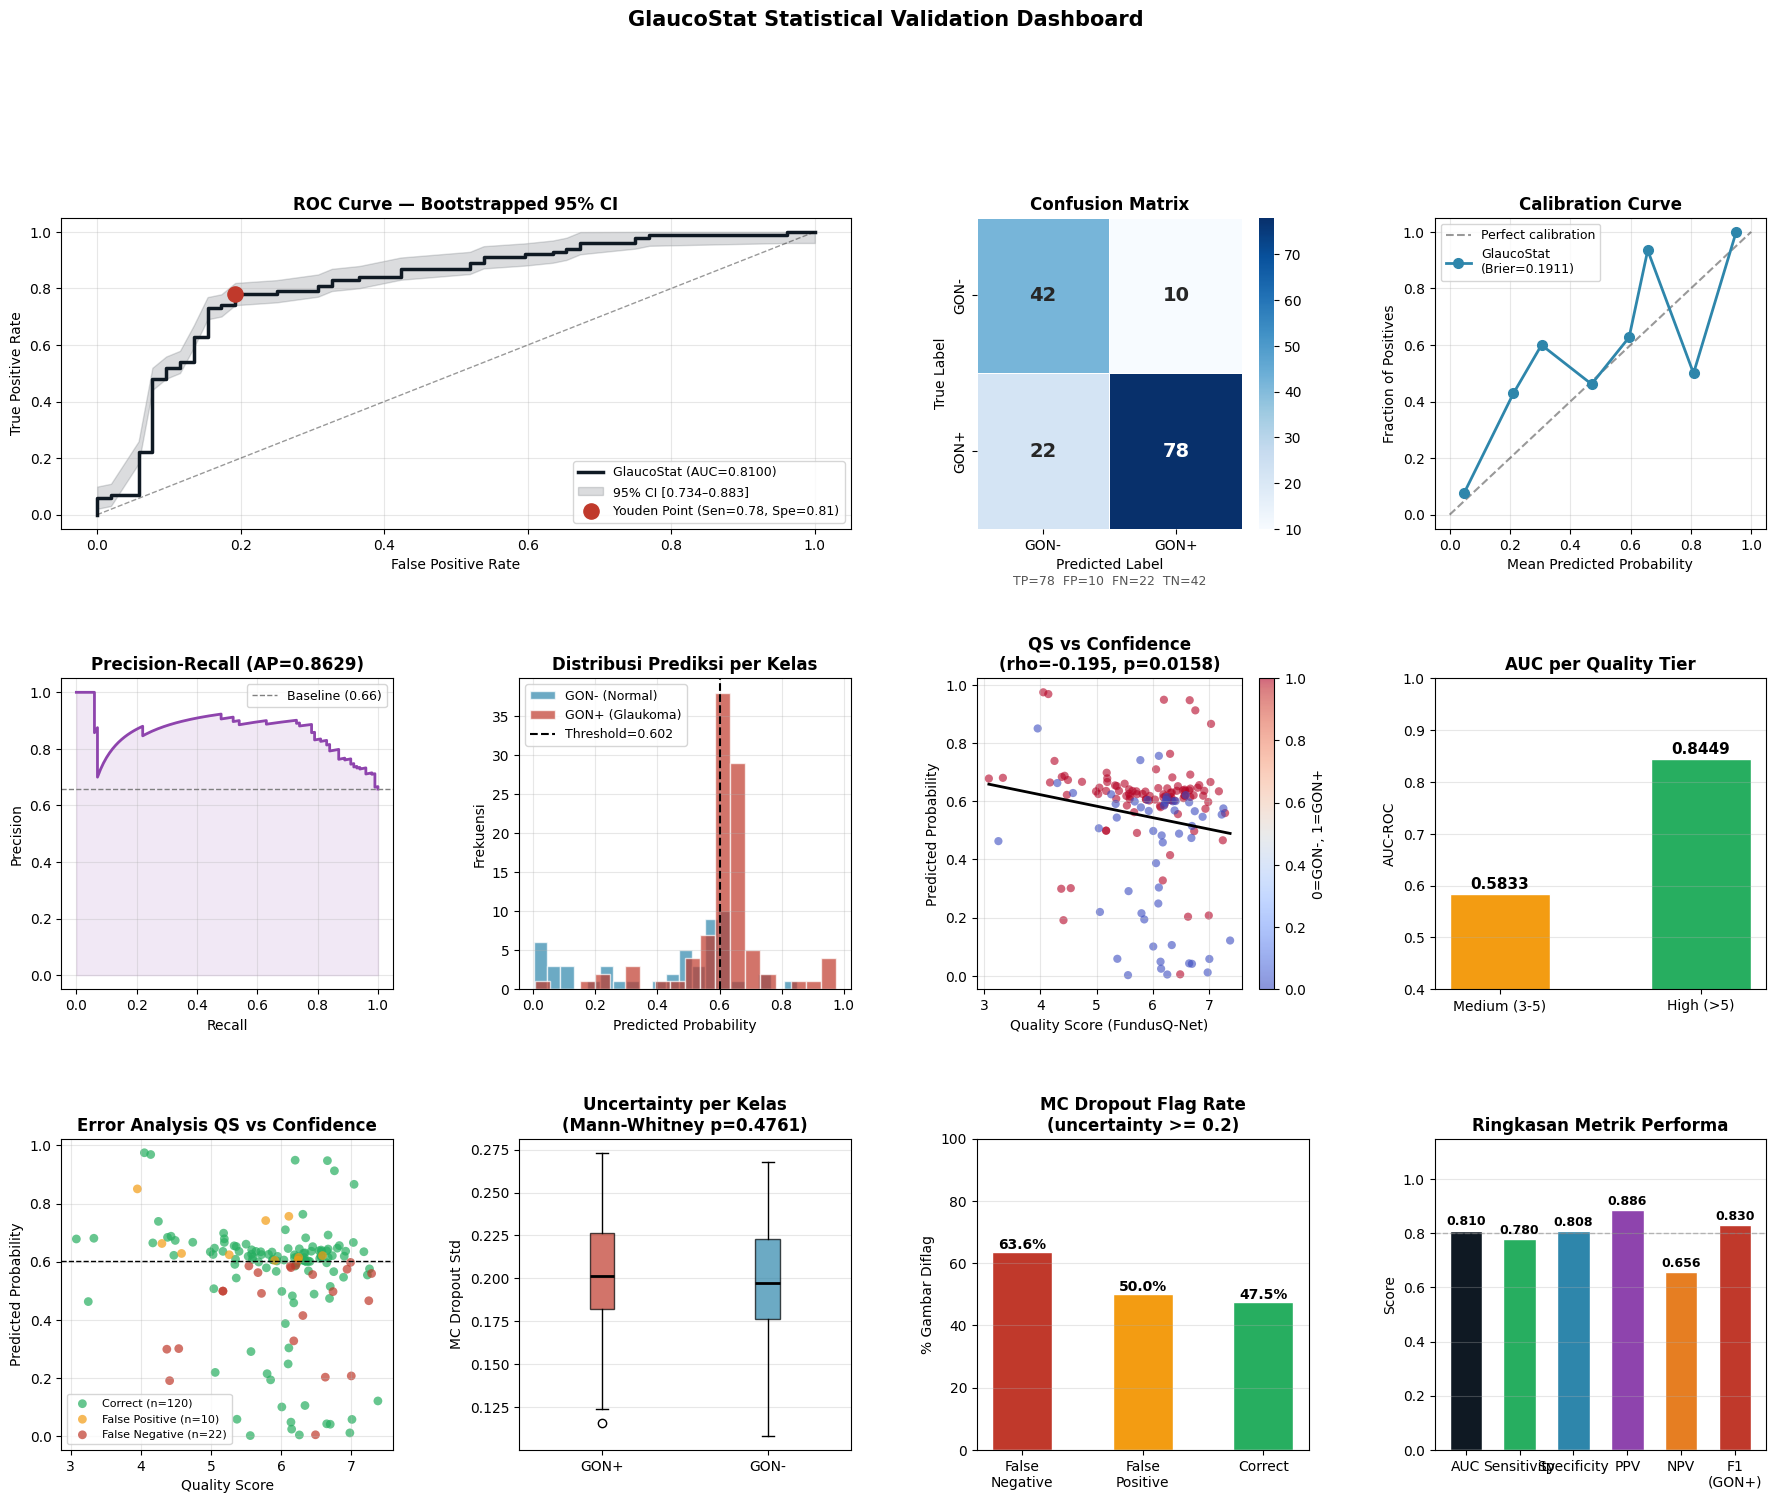

Step 7 selesaivisualisasi disimpan.


In [ ]:
# STEP 7 — VISUALISASI STATISTIK LENGKAP
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix, precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve
import numpy as np

fig = plt.figure(figsize=(22, 16))
fig.suptitle('GlaucoStat Statistical Validation Dashboard', fontsize=15, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.48, wspace=0.38)

ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(fpr, tpr, color='#0F1923', linewidth=2.5,
         label=f'GlaucoStat (AUC={auc_mean:.4f})')
ax1.fill_between(fpr,
                 np.clip(np.interp(fpr, fpr, tpr) - auc_se, 0, 1),
                 np.clip(np.interp(fpr, fpr, tpr) + auc_se, 0, 1),
                 alpha=0.15, color='#0F1923',
                 label=f'95% CI [{auc_lower:.3f}–{auc_upper:.3f}]')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.4, linewidth=1)
ax1.scatter([1 - opt_specificity], [opt_sensitivity],
            color='#C0392B', s=120, zorder=5,
            label=f'Youden Point (Sen={opt_sensitivity:.2f}, Spe={opt_specificity:.2f})')
ax1.set_title('ROC Curve — Bootstrapped 95% CI', fontweight='bold')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 2])
cm_val = confusion_matrix(y_test, y_pred_binary)
sns.heatmap(cm_val, annot=True, fmt='d', ax=ax2, cmap='Blues',
            xticklabels=['GON-', 'GON+'],
            yticklabels=['GON-', 'GON+'],
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
ax2.set_title('Confusion Matrix', fontweight='bold')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')
tn_v, fp_v, fn_v, tp_v = cm_val.ravel()
ax2.text(0.5, -0.18, f'TP={tp_v}  FP={fp_v}  FN={fn_v}  TN={tn_v}',
         transform=ax2.transAxes, ha='center', fontsize=9, color='#555')

ax3 = fig.add_subplot(gs[0, 3])
frac_pos, mean_pred_cal = calibration_curve(y_test, y_pred_proba, n_bins=8)
ax3.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')
ax3.plot(mean_pred_cal, frac_pos, 'o-', color='#2E86AB', linewidth=2,
         markersize=7, label=f'GlaucoStat\n(Brier={brier:.4f})')
ax3.set_title('Calibration Curve', fontweight='bold')
ax3.set_xlabel('Mean Predicted Probability')
ax3.set_ylabel('Fraction of Positives')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, 0])
precision_arr, recall_arr, _ = precision_recall_curve(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)
ax4.plot(recall_arr, precision_arr, color='#8E44AD', linewidth=2)
ax4.fill_between(recall_arr, precision_arr, alpha=0.12, color='#8E44AD')
ax4.axhline(y_test.mean(), color='gray', linestyle='--', linewidth=1,
            label=f'Baseline ({y_test.mean():.2f})')
ax4.set_title(f'Precision-Recall (AP={ap:.4f})', fontweight='bold')
ax4.set_xlabel('Recall')
ax4.set_ylabel('Precision')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(y_pred_proba[y_test == 0], bins=20, alpha=0.7,
         color='#2E86AB', label='GON- (Normal)', edgecolor='white')
ax5.hist(y_pred_proba[y_test == 1], bins=20, alpha=0.7,
         color='#C0392B', label='GON+ (Glaukoma)', edgecolor='white')
ax5.axvline(opt_threshold, color='black', linestyle='--', linewidth=1.5,
            label=f'Threshold={opt_threshold:.3f}')
ax5.set_title('Distribusi Prediksi per Kelas', fontweight='bold')
ax5.set_xlabel('Predicted Probability')
ax5.set_ylabel('Frekuensi')
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2])
scatter6 = ax6.scatter(
    df_test_copy['Quality Score'], df_test_copy['y_pred_proba'],
    c=df_test_copy['label_binary'], cmap='coolwarm',
    alpha=0.6, s=35, edgecolors='none'
)
x_line = np.linspace(df_test_copy['Quality Score'].min(),
                     df_test_copy['Quality Score'].max(), 100)
z6 = np.polyfit(df_test_copy['Quality Score'], df_test_copy['y_pred_proba'], 1)
ax6.plot(x_line, np.poly1d(z6)(x_line), 'k-', linewidth=2)
ax6.set_title(f'QS vs Confidence\n(rho={spearman_rho:.3f}, p={spearman_p:.4f})',
              fontweight='bold')
ax6.set_xlabel('Quality Score (FundusQ-Net)')
ax6.set_ylabel('Predicted Probability')
plt.colorbar(scatter6, ax=ax6, label='0=GON-, 1=GON+')
ax6.grid(alpha=0.3)

ax7 = fig.add_subplot(gs[1, 3])
tier_names  = list(tier_results.keys())
tier_values = list(tier_results.values())
bars7 = ax7.bar(tier_names, tier_values,
                color=['#F39C12', '#27AE60'][:len(tier_names)],
                edgecolor='white', width=0.5)
ax7.set_ylim(0.4, 1.0)
ax7.set_title('AUC per Quality Tier', fontweight='bold')
ax7.set_ylabel('AUC-ROC')
ax7.grid(alpha=0.3, axis='y')
for bar, val in zip(bars7, tier_values):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)

ax8 = fig.add_subplot(gs[2, 0])
error_colors = {'Correct': '#27AE60', 'False Positive': '#F39C12', 'False Negative': '#C0392B'}
for etype, color in error_colors.items():
    mask = df_test_copy['error_type'] == etype
    if mask.sum() > 0:
        ax8.scatter(
            df_test_copy[mask]['Quality Score'],
            df_test_copy[mask]['y_pred_proba'],
            c=color, label=f'{etype} (n={mask.sum()})',
            alpha=0.7, s=40, edgecolors='none'
        )
ax8.axhline(opt_threshold, color='black', linestyle='--', linewidth=1)
ax8.set_title('Error Analysis QS vs Confidence', fontweight='bold')
ax8.set_xlabel('Quality Score')
ax8.set_ylabel('Predicted Probability')
ax8.legend(fontsize=8)
ax8.grid(alpha=0.3)

ax9 = fig.add_subplot(gs[2, 1])
bp = ax9.boxplot(
    [mc_std[y_test == 1], mc_std[y_test == 0]],
    labels=['GON+', 'GON-'], patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
bp['boxes'][0].set_facecolor('#C0392B'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#2E86AB'); bp['boxes'][1].set_alpha(0.7)
ax9.set_title(f'Uncertainty per Kelas\n(Mann-Whitney p={p_unc:.4f})',
              fontweight='bold')
ax9.set_ylabel('MC Dropout Std')
ax9.grid(alpha=0.3, axis='y')

ax10 = fig.add_subplot(gs[2, 2])
unc_threshold_line = 0.20
fn_flagged  = (fn_df['mc_std'] >= unc_threshold_line).sum()
fp_flagged  = (fp_df['mc_std'] >= unc_threshold_line).sum()
cor_flagged = (correct_df['mc_std'] >= unc_threshold_line).sum()
categories  = ['False\nNegative', 'False\nPositive', 'Correct']
flagged_pct = [fn_flagged/len(fn_df)*100, fp_flagged/len(fp_df)*100,
               cor_flagged/len(correct_df)*100]
bars10 = ax10.bar(categories, flagged_pct,
                  color=['#C0392B', '#F39C12', '#27AE60'],
                  edgecolor='white', width=0.5)
ax10.set_title(f'MC Dropout Flag Rate\n(uncertainty >= {unc_threshold_line})',
               fontweight='bold')
ax10.set_ylabel('% Gambar Diflag')
ax10.set_ylim(0, 100)
ax10.grid(alpha=0.3, axis='y')
for bar, val in zip(bars10, flagged_pct):
    ax10.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
              f'{val:.1f}%', ha='center', fontweight='bold')

ax11 = fig.add_subplot(gs[2, 3])
npv = tn_v / (tn_v + fn_v) if (tn_v + fn_v) > 0 else 0
ppv = tp_v / (tp_v + fp_v) if (tp_v + fp_v) > 0 else 0
f1_gon_pos = 2*tp_v / (2*tp_v + fp_v + fn_v) if (2*tp_v + fp_v + fn_v) > 0 else 0
metrics_names  = ['AUC', 'Sensitivity', 'Specificity', 'PPV', 'NPV', 'F1\n(GON+)']
metrics_values = [auc_mean, opt_sensitivity, opt_specificity, ppv, npv, f1_gon_pos]
bar_colors11   = ['#0F1923', '#27AE60', '#2E86AB', '#8E44AD', '#E67E22', '#C0392B']
bars11 = ax11.bar(metrics_names, metrics_values,
                  color=bar_colors11, edgecolor='white', width=0.6)
ax11.set_ylim(0, 1.15)
ax11.set_title('Ringkasan Metrik Performa', fontweight='bold')
ax11.set_ylabel('Score')
ax11.grid(alpha=0.3, axis='y')
ax11.axhline(0.8, color='gray', linestyle='--', linewidth=1, alpha=0.5)
for bar, val in zip(bars11, metrics_values):
    ax11.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
              f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.savefig('glaucostat_artifacts/statistical_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Step 7 selesaivisualisasi disimpan.")

# Step 8: GRAD-CAM EXPLAINABILITY

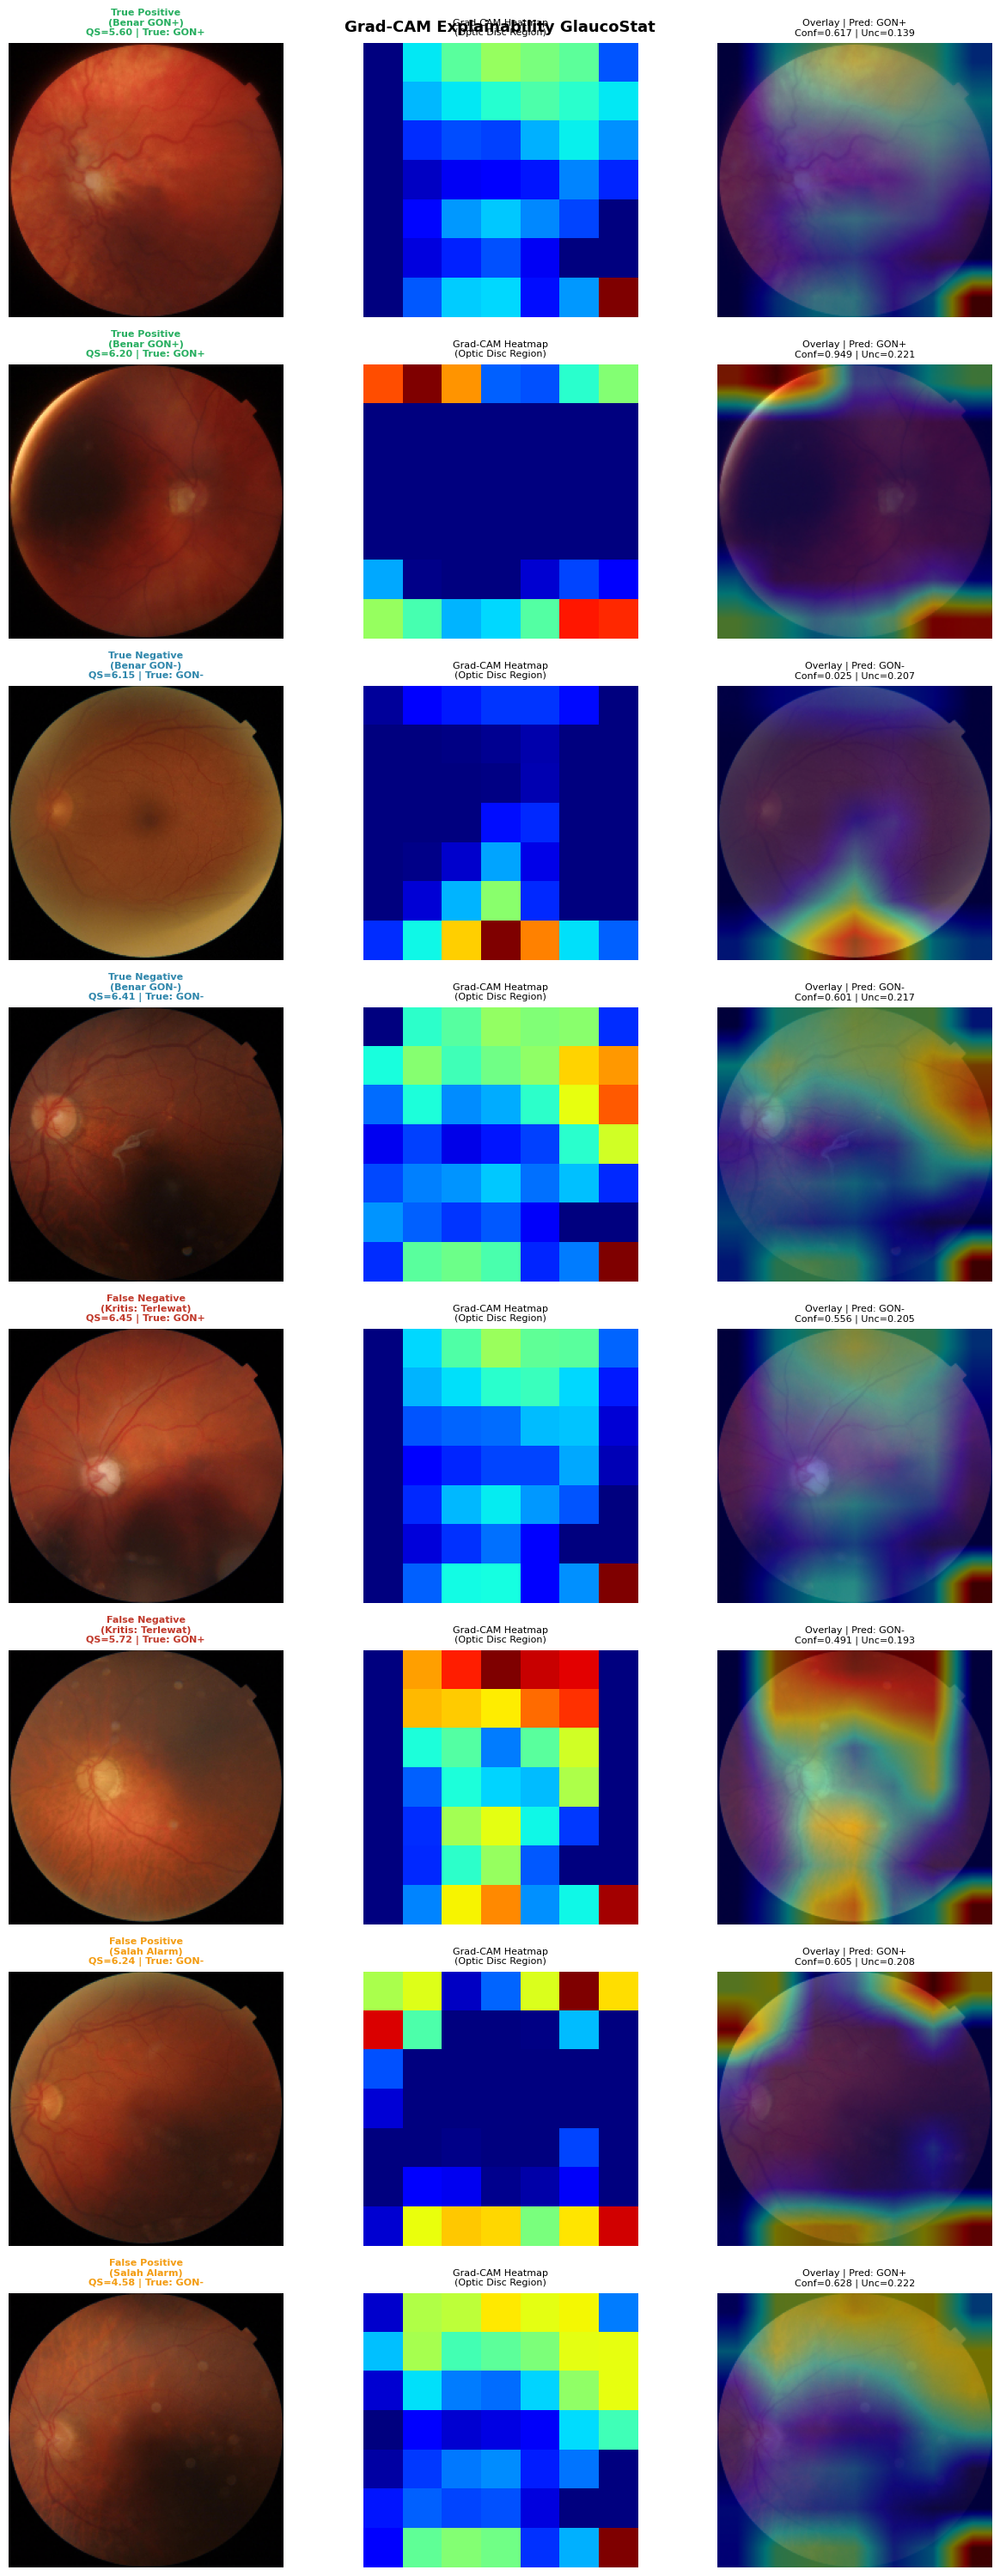

Step 8 selesai Grad-CAM disimpan.


In [ ]:
import tensorflow as tf
import cv2

def compute_gradcam(model, img_array, qs_array, conv_layer_name='top_conv'):
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        inputs = {
            'image_input': tf.cast(img_array, tf.float32),
            'quality_input': tf.cast(qs_array, tf.float32)
        }
        conv_outputs, predictions = grad_model(inputs)
        loss = predictions[:, 0]
    grads       = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap      = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img_norm, heatmap, alpha=0.45):
    heatmap_resized = cv2.resize(heatmap, (img_norm.shape[1], img_norm.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    img_uint8       = np.uint8(255 * np.clip(img_norm, 0, 1))
    return cv2.addWeighted(img_uint8, 1 - alpha, heatmap_colored, alpha, 0)

def denormalize_img(img_normalized):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = img_normalized * std + mean
    return np.clip(img, 0, 1)

sample_categories = {
    'True Positive\n(Benar GON+)' : df_test_copy[(df_test_copy['error_type'] == 'Correct') & (df_test_copy['label_binary'] == 1)].index.tolist(),
    'True Negative\n(Benar GON-)' : df_test_copy[(df_test_copy['error_type'] == 'Correct') & (df_test_copy['label_binary'] == 0)].index.tolist(),
    'False Negative\n(Kritis: Terlewat)': df_test_copy[df_test_copy['error_type'] == 'False Negative'].index.tolist(),
    'False Positive\n(Salah Alarm)'     : df_test_copy[df_test_copy['error_type'] == 'False Positive'].index.tolist(),
}

selected_samples = []
sample_labels    = []
for cat_name, indices in sample_categories.items():
    if len(indices) >= 2:
        chosen = np.random.choice(indices, 2, replace=False)
    elif len(indices) == 1:
        chosen = indices
    else:
        continue
    for idx in chosen:
        selected_samples.append(idx)
        sample_labels.append(cat_name)

n_samples = len(selected_samples)
fig, axes = plt.subplots(n_samples, 3, figsize=(13, n_samples * 3.8))
fig.suptitle('Grad-CAM Explainability GlaucoStat', fontsize=13, fontweight='bold')

title_colors = {
    'True Positive\n(Benar GON+)' : '#27AE60',
    'True Negative\n(Benar GON-)' : '#2E86AB',
    'False Negative\n(Kritis: Terlewat)': '#C0392B',
    'False Positive\n(Salah Alarm)'     : '#F39C12',
}

for row_idx, (sample_idx, cat_label) in enumerate(zip(selected_samples, sample_labels)):
    img_preprocessed = X_test_img[sample_idx:sample_idx+1]
    qs_preprocessed  = X_test_qs[sample_idx:sample_idx+1]
    img_display      = denormalize_img(X_test_img[sample_idx])
    sample_row       = df_test_copy.iloc[sample_idx]

    try:
        heatmap = compute_gradcam(model, img_preprocessed, qs_preprocessed)
        overlay = overlay_gradcam(img_display, heatmap)
        has_gradcam = True
    except Exception:
        has_gradcam = False

    true_label = 'GON+' if sample_row['label_binary'] == 1 else 'GON-'
    pred_label = 'GON+' if sample_row['pred_bin'] == 1 else 'GON-'
    color      = title_colors.get(cat_label, 'black')

    axes[row_idx, 0].imshow(img_display)
    axes[row_idx, 0].set_title(
        f'{cat_label}\nQS={sample_row["Quality Score"]:.2f} | True: {true_label}',
        fontsize=8, color=color, fontweight='bold'
    )
    axes[row_idx, 0].axis('off')

    if has_gradcam:
        axes[row_idx, 1].imshow(heatmap, cmap='jet')
        axes[row_idx, 1].set_title('Grad-CAM Heatmap\n(Optic Disc Region)', fontsize=8)
    else:
        axes[row_idx, 1].text(0.5, 0.5, 'Grad-CAM\ntidak tersedia',
                              ha='center', va='center', transform=axes[row_idx, 1].transAxes)
    axes[row_idx, 1].axis('off')

    if has_gradcam:
        axes[row_idx, 2].imshow(overlay)
    else:
        axes[row_idx, 2].imshow(img_display)
    axes[row_idx, 2].set_title(
        f'Overlay | Pred: {pred_label}\nConf={sample_row["y_pred_proba"]:.3f} | Unc={sample_row["mc_std"]:.3f}',
        fontsize=8
    )
    axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.savefig('glaucostat_artifacts/gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Step 8 selesai Grad-CAM disimpan.")

# STEP 9: RINGKASAN STATISTIK FINAL

In [ ]:
ppv = tp_v / (tp_v + fp_v) if (tp_v + fp_v) > 0 else 0
npv = tn_v / (tn_v + fn_v) if (tn_v + fn_v) > 0 else 0
f1  = 2*tp_v / (2*tp_v + fp_v + fn_v) if (2*tp_v + fp_v + fn_v) > 0 else 0

summary = {
    'Metrik'     : [
        'Bootstrapped AUC (1000 iter)',
        '95% Confidence Interval',
        'Standard Error AUC',
        'Optimal Threshold (Youden)',
        'Youden Index',
        'Sensitivity (Recall GON+)',
        'Specificity',
        'Precision / PPV (GON+)',
        'NPV (GON-)',
        'F1-Score (GON+)',
        'Brier Score',
        'Average Precision (PR-AUC)',
        'AUC High Quality Tier',
        'AUC Medium Quality Tier',
        'McNemar Test p-value (High vs Medium)',
        'Spearman rho (QS vs Confidence)',
        'Spearman p (QS vs Confidence)',
        'MC Dropout Mean Uncertainty',
        'MC Dropout FN Flag Rate (>= 0.20)',
        'Total Test Samples',
        'True Positive', 'True Negative',
        'False Positive', 'False Negative',
    ],
    'Nilai'      : [
        f'{auc_mean:.4f}',
        f'[{auc_lower:.4f}, {auc_upper:.4f}]',
        f'{auc_se:.4f}',
        f'{opt_threshold:.4f}',
        f'{youden_index[best_idx]:.4f}',
        f'{opt_sensitivity:.4f}',
        f'{opt_specificity:.4f}',
        f'{ppv:.4f}',
        f'{npv:.4f}',
        f'{f1:.4f}',
        f'{brier:.4f}',
        f'{ap:.4f}',
        f'{tier_results.get("High (>5)", 0):.4f}',
        f'{tier_results.get("Medium (3-5)", 0):.4f}',
        f'{result_mcnemar.pvalue:.4f}',
        f'{spearman_rho:.4f}',
        f'{spearman_p:.4f}',
        f'{mc_std.mean():.4f}',
        f'{fn_high_unc}/{len(fn_df)} ({fn_high_unc/len(fn_df)*100:.1f}%)',
        f'{len(y_test)}',
        f'{tp_v}', f'{tn_v}', f'{fp_v}', f'{fn_v}',
    ],
    'Interpretasi': [
        'Discriminative power keseluruhan',
        'Interval kepercayaan 95% via bootstrap',
        'Variabilitas estimasi AUC',
        'Optimized via Youden Index untuk skrining',
        'Sensitivity + Specificity - 1',
        'Proporsi glaukoma terdeteksi dengan benar',
        'Proporsi normal terklasifikasi benar',
        'Ketepatan prediksi positif',
        'Ketepatan prediksi negatif',
        'Harmonic mean precision & recall',
        'Kalibrasi probabilitas (0=perfect)',
        'Area under Precision-Recall curve',
        'Performa pada gambar berkualitas tinggi',
        'Performa pada gambar berkualitas sedang',
        'Signifikan (< 0.05 = berbeda)',
        'Korelasi kualitas gambar vs keyakinan model',
        'Signifikan jika < 0.05',
        'Rata-rata epistemic uncertainty',
        'Kasus kritis yang bisa diflag otomatis',
        'Total gambar evaluasi',
        'Glaukoma terdeteksi benar', 'Normal terdeteksi benar',
        'Normal salah diprediksi glaukoma', 'Glaukoma terlewat',
    ]
}

summary_df = pd.DataFrame(summary)
print("RINGKASAN STATISTIK FINAL GlaucoStat")
print("(Siap disalin ke esai / tabel publikasi)\n")
print(summary_df.to_string(index=False))

summary_df.to_csv('glaucostat_artifacts/statistical_summary.csv', index=False)
print("\nRingkasan disimpan ke glaucostat_artifacts/statistical_summary.csv")

RINGKASAN STATISTIK FINAL GlaucoStat
(Siap disalin ke esai / tabel publikasi)

                               Metrik            Nilai                                Interpretasi
         Bootstrapped AUC (1000 iter)           0.8100            Discriminative power keseluruhan
              95% Confidence Interval [0.7343, 0.8825]      Interval kepercayaan 95% via bootstrap
                   Standard Error AUC           0.0393                   Variabilitas estimasi AUC
           Optimal Threshold (Youden)           0.6022   Optimized via Youden Index untuk skrining
                         Youden Index           0.5877               Sensitivity + Specificity - 1
            Sensitivity (Recall GON+)           0.7800   Proporsi glaukoma terdeteksi dengan benar
                          Specificity           0.8077        Proporsi normal terklasifikasi benar
               Precision / PPV (GON+)           0.8864                  Ketepatan prediksi positif
                           NPV

In [ ]:
# STEP 9.5 — EXPORT SEMUA ARTEFAK & DOWNLOAD
import json
import os
import numpy as np
from sklearn.metrics import roc_curve
from sklearn.calibration import calibration_curve
from google.colab import files

fpr_export, tpr_export, _ = roc_curve(y_test, y_pred_proba)
pd.DataFrame({'fpr': fpr_export, 'tpr': tpr_export}).to_csv(
    'glaucostat_artifacts/roc_data.csv', index=False
)

frac_pos_exp, mean_pred_exp = calibration_curve(y_test, y_pred_proba, n_bins=8)
pd.DataFrame({'mean_pred': mean_pred_exp, 'fraction_pos': frac_pos_exp}).to_csv(
    'glaucostat_artifacts/calibration_data.csv', index=False
)

model_config = {
    'model_name'      : 'GlaucoStat',
    'backbone'        : 'EfficientNetB0',
    'img_size'        : 224,
    'qs_mean'         : float(QS_MEAN),
    'qs_std'          : float(QS_STD),
    'optimal_threshold': float(opt_threshold),
    'conv_layer'      : 'top_conv',
    'bootstrap_auc'   : {
        'mean'    : float(auc_mean),
        'ci_lower': float(auc_lower),
        'ci_upper': float(auc_upper),
        'se'      : float(auc_se),
    },
    'sensitivity'     : float(opt_sensitivity),
    'specificity'     : float(opt_specificity),
    'youden_index'    : float(youden_index[best_idx]),
    'brier_score'     : float(brier),
    'average_precision': float(ap),
    'spearman_rho'    : float(spearman_rho),
    'spearman_p'      : float(spearman_p),
    'tier_auc'        : {k: float(v) for k, v in tier_results.items()},
    'mcnemar_pvalue'  : float(result_mcnemar.pvalue),
    'mc_uncertainty_mean': float(mc_std.mean()),
    'fn_flag_rate'    : float(fn_high_unc / len(fn_df)),
    'confusion_matrix': {
        'tp': int(tp_v), 'tn': int(tn_v),
        'fp': int(fp_v), 'fn': int(fn_v)
    },
    'n_train'         : int(len(y_train)),
    'n_test'          : int(len(y_test)),
    'ppv'             : float(ppv),
    'npv'             : float(npv),
    'f1_gon_pos'      : float(f1),
}

with open('glaucostat_artifacts/model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print("Semua artefak berhasil disimpan:")
for fname in sorted(os.listdir('glaucostat_artifacts')):
    fpath = os.path.join('glaucostat_artifacts', fname)
    size  = os.path.getsize(fpath) / 1024
    print(f"  {fname:45}: {size:8.1f} KB")

print("\nMembuat zip untuk download...")
import shutil
shutil.make_archive('glaucostat_artifacts', 'zip', 'glaucostat_artifacts')
print("ZIP berhasil dibuat: glaucostat_artifacts.zip")

print("\nMemulai download...")
files.download('glaucostat_artifacts.zip')
print("Download selesai. Ekstrak dan pindahkan isinya ke folder VSCode bersama app.py")

Semua artefak berhasil disimpan:
  best_model.keras                             :  32536.3 KB
  calibration_data.csv                         :      0.3 KB
  gradcam_results.png                          :   3250.4 KB
  model_config.json                            :      1.0 KB
  roc_data.csv                                 :      1.1 KB
  statistical_summary.csv                      :      1.5 KB
  statistical_validation.png                   :    504.2 KB
  training_history.png                         :    180.8 KB

Membuat zip untuk download...
ZIP berhasil dibuat: glaucostat_artifacts.zip

Memulai download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download selesai. Ekstrak dan pindahkan isinya ke folder VSCode bersama app.py
